# NMF - Text Processing, Parameter Selection, and Topic Models

Now we look at the more advanced task of parameter selection for NMF topic modelling - namely, selecting a useful value for the number of topics *k*.<br />
We can load the TF-IDF normalized document-term matrix and list of terms that we stored earlier using Joblib earlier in NMF-Preprocessing or create the TF-IDF normalized document-term matrix here again.

### This section deals with preprocessing of a corpus of unstructed text documents using *scikit-learn* and builds a matrix of token counts using TfidfVectorizer along with the terms and snippets.  
<li> Tokenized using the Gensim.util's simple_process() function</li>
<li> Lemmatized using SpaCy POS-tagger to keep noun, adverb, verb, and adjective </li> 
<li> Used TfidfVectorizer available in sklearn.feature_extraction.text: 
<ul><li> a custom stop-words list was used</li>
<li> used token-pattern like '[a-zA-Z0-9]{3,}' to use longer than 3 alpha-numberic characters</li>
<li> min_df is set to 5, to make consistent with the LDA model</li>
</ul>
</li>
<li> Saved the  pickle files articles-raw.pkl and articles-tfidf.pkl to be used in the other iPython scripts. It “serialises” the object first before writing it to file. Pickling is a way to convert a python object (list, dict, etc.) into a character stream.</li>

In [1]:
#from sklearn.externals import joblib
#(A,terms,snippets) = joblib.load( "articles-tfidf.pkl" )
#print( "Loaded %d X %d document-term matrix" % (A.shape[0], A.shape[1]) )

Loaded 8894 X 24175 document-term matrix


### Loading the documents in the "nytimes_articles.csv" file to build a word embedding

As our sample corpus of text, we will use a corpus of news articles collected in 2016. These articles have been stored in a single file and formatted so that one article appears on each line. We will load these articles into a list, and also create a short snippet of text for each document.

In [1]:
# Read the documents from the input file again 
import os.path
raw_documents = []
snippets = []
with open( os.path.join("nytimes_articles.csv") ,"r", encoding="utf-8") as fin:
    for line in fin.readlines():
        text = line.strip()
        raw_documents.append( text )
        # keep a short snippet of up to 100 characters as a title for each article
        snippets.append( text[0:min(len(text),100)] )
print("Read %d raw text documents" % len(raw_documents))

Read 8894 raw text documents


### Read the custom stopword list:

In [2]:
# create a list of stop words
def isLineEmpty(line):
    return len(line.strip()) == 0

custom_stop_words = []
with open( "newStopwords.txt", "r" ) as fin:
    for line in fin.readlines():
        if not isLineEmpty(line):
            custom_stop_words.append( line.strip() )
# note that we need to make it hashable
print("Stopword list has %d entries" % len(custom_stop_words) )
#custom_stop_words

Stopword list has 599 entries


In [4]:
# tokenize the text
import gensim, spacy
def tokenized(texts):
    for txt in texts:
        yield(gensim.utils.simple_preprocess(str(txt), deacc=True))  # deacc=True removes punctuations

data_words = list(tokenized(raw_documents))

#print(data_words[:1])

ModuleNotFoundError: No module named 'gensim'

In [4]:
# lemmatize the tokenized list
def lemmatization(texts, allowed_postags=['NOUN', 'ADJ', 'VERB', 'ADV']):
    """https://spacy.io/api/annotation"""
    texts_out = []
    for sent in texts:
        doc = nlp(" ".join(sent)) 
        texts_out.append(" ".join([token.lemma_ if token.lemma_ not in ['-PRON-'] else '' for token in doc if token.pos_ in allowed_postags]))
    return texts_out

# Initialize spacy 'en' model, keeping only tagger component (for efficiency)
# Run in terminal: python3 -m spacy download en
nlp = spacy.load('en', disable=['parser', 'ner'])

# Do lemmatization keeping only Noun, Adj, Verb, Adverb
data_lemmatized = lemmatization(data_words, allowed_postags=['NOUN', 'ADJ', 'VERB', 'ADV'])

#print(data_lemmatized[:1])

### Applying Term Weighting with TF-IDF to be used in the NMF model 

We can improve the usefulness of the document-term matrix by giving more weight to the more "important" terms. The most common normalisation is *term frequency–inverse document frequency* (TF-IDF). In Scikit-learn, we can generate at TF-IDF weighted document-term matrix by using *TfidfVectorizer* in place of *CountVectorizer*.

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
# we can pass in the same preprocessing parameters as in countVectorizer
tivectorizer = TfidfVectorizer(analyzer='word',       
                             min_df=5,                        # minimum reqd occurences of a word 
                             stop_words=custom_stop_words,   # remove stop words
                             lowercase=True,                 # convert all words to lowercase
                             token_pattern='[a-zA-Z0-9]{3,}'  # num chars > 3
                            )
A= tivectorizer.fit_transform(data_lemmatized)
print( "Created %d X %d TF-IDF-normalized document-term matrix" % (A.shape[0], A.shape[1]) )

Created 8894 X 24174 TF-IDF-normalized document-term matrix


In [7]:
# extract the resulting vocabulary
terms = tivectorizer.get_feature_names()
print("Vocabulary has %d distinct terms" % len(terms))

Vocabulary has 24174 distinct terms


In [8]:
import operator
def rank_terms( A, terms ):
    # get the sums over each column
    sums = A.sum(axis=0)
    # map weights to the terms
    weights = {}
    for col, term in enumerate(terms):
        weights[term] = sums[0,col]
    # rank the terms by their weight over all documents
    return sorted(weights.items(), key=operator.itemgetter(1), reverse=True)

In [9]:
ranking = rank_terms( A, terms )
for i, pair in enumerate( ranking[0:20] ):
    print( "%02d. %s (%.2f)" % ( i+1, pair[0], pair[1] ) )

01. trump (193.00)
02. company (154.38)
03. time (151.27)
04. game (149.94)
05. people (148.55)
06. city (119.42)
07. york (111.94)
08. play (107.14)
09. day (105.15)
10. win (104.80)
11. include (102.65)
12. team (100.14)
13. american (99.91)
14. police (97.13)
15. season (96.03)
16. united (95.29)
17. republican (95.24)
18. call (94.51)
19. woman (94.48)
20. week (94.03)


In [ ]:
#joblib.dump((A,terms,snippets), "articles-tfidf.pkl") 

### Create the NMF Topic Models 

A common approach for parameter selection is to measure and compare the topic coherence of models generated for different values of *k*. <br />
We need to start by pre-specifying an initial range of "sensible" values:

In [10]:
kmin, kmax = 10, 30

#### Apply NMF for each of these values. 10<= k <=30,  using the TF-IDF matrix built earlier:

In [11]:
from sklearn import decomposition
topic_models = []
# try each value of k
for k in range(kmin,kmax+1):
    print("Applying NMF for k=%d ..." % k )
    # run NMF
    model = decomposition.NMF( init="nndsvd", n_components=k ) 
    W = model.fit_transform( A ) # using the TF-IDF normalized doc-term matrix
    H = model.components_    
    # store for later
    topic_models.append( (k,W,H) )

Applying NMF for k=10 ...
Applying NMF for k=11 ...
Applying NMF for k=12 ...
Applying NMF for k=13 ...
Applying NMF for k=14 ...
Applying NMF for k=15 ...
Applying NMF for k=16 ...
Applying NMF for k=17 ...
Applying NMF for k=18 ...
Applying NMF for k=19 ...
Applying NMF for k=20 ...
Applying NMF for k=21 ...
Applying NMF for k=22 ...
Applying NMF for k=23 ...
Applying NMF for k=24 ...
Applying NMF for k=25 ...
Applying NMF for k=26 ...
Applying NMF for k=27 ...
Applying NMF for k=28 ...
Applying NMF for k=29 ...
Applying NMF for k=30 ...


### Use a topic coherence measure, TC-W2V, to select the number of topics

To select the number of topics, here we will use a *topic coherence* measure called TC-W2V. This measure relies on the use of a *word embedding* model constructed from our corpus. So in this step we will use the *Gensim* implementation of Word2Vec to build a Word2Vec model based on our collection of news articles.

First, we need to define a class that will generate documents in a form that can be consumed by Gensim's Word2Vec implementation:

In [12]:
import re
class TokenGenerator:
    def __init__( self, documents, stopwords ):
        self.documents = documents
        self.stopwords = stopwords
        self.tokenizer = re.compile( r"(?u)\b\w\w+\b" )

    def __iter__( self ):
        print("Building Word2Vec model ...")
        for doc in self.documents:
            tokens = []
            for tok in self.tokenizer.findall( doc ):
                if tok in self.stopwords:
                    tokens.append( "<stopword>" )
                elif len(tok) >= 2:
                    tokens.append( tok )
            yield tokens

### Now build a Skipgram Word2Vec model from all documents in the input file using *Gensim*.
### <li> Note: We used the lemmatized text as the input using the custom stop-words list we set out.</li>

In [13]:
import gensim
docgen = TokenGenerator( data_lemmatized, custom_stop_words )

# the model has 500 dimensions, the minimum document-term frequency is set to 5 to be consistent with the LDA model we created earlier. 
w2v_model = gensim.models.Word2Vec(docgen, size=500, min_count=5, sg=1)

Building Word2Vec model ...
Building Word2Vec model ...
Building Word2Vec model ...
Building Word2Vec model ...
Building Word2Vec model ...
Building Word2Vec model ...


In [16]:
print( "Model has %d terms" % len(w2v_model.wv.vocab) )

Model has 29535 terms


Save for later use, so that we do not need to rebuild it:

In [14]:
w2v_model.save("w2v-model.bin")

In [10]:
# To re-load this model later, run
#w2v_model = gensim.models.Word2Vec.load("w2v-model.bin")

### Selecting the Number of Topics

Once we have our Word2vec model, we can use it as part of our *topic coherence* approach to evaluate the different NMF topic models that we created previously. To do this, we will implement a simple version of the TC-W2V coherence measure.

We use the Word2vec model to calculate coherence scores for each of these models. We will define this coherence score as follows:

In [15]:
def calculate_coherence( w2v_model, term_rankings ):
    overall_coherence = 0.0
    for topic_index in range(len(term_rankings)):
        # check each pair of terms
        pair_scores = []
        for pair in combinations( term_rankings[topic_index], 2 ):
            pair_scores.append( w2v_model.similarity(pair[0], pair[1]) )
        # get the mean for all pairs in this topic
        topic_score = sum(pair_scores) / len(pair_scores)
        overall_coherence += topic_score
    # get the mean score across all topics
    return overall_coherence / len(term_rankings)

We also define a function to get the topic descriptor (i.e. list of top terms) for each topic:

In [17]:
import numpy as np
def get_descriptor( all_terms, H, topic_index, top ):
    # reverse sort the values to sort the indices
    top_indices = np.argsort( H[topic_index,:] )[::-1]
    # now get the terms corresponding to the top-ranked indices
    top_terms = []
    for term_index in top_indices[0:top]:
        top_terms.append( all_terms[term_index] )
    return top_terms

### Now process each of the topic models for different values of *k*, which we set out earlier from 4 to 30. 

In [18]:
from itertools import combinations
k_values = []
coherences = []
for (k,W,H) in topic_models:
    # Get all of the topic descriptors - the term_rankings, based on top 10 terms
    term_rankings = []
    for topic_index in range(k):
        term_rankings.append( get_descriptor( terms, H, topic_index, 10 ) )
    # Now calculate the coherence based on our Word2vec model
    k_values.append( k )
    coherences.append( calculate_coherence( w2v_model, term_rankings ) )
    print("K=%02d: Coherence=%.4f" % ( k, coherences[-1] ) )

/home/cc/.local/lib/python3.5/site-packages/ipykernel_launcher.py:7: DeprecationWarning: Call to deprecated `similarity` (Method will be removed in 4.0.0, use self.wv.similarity() instead).
  import sys


K=10: Coherence=0.3805
K=11: Coherence=0.3775
K=12: Coherence=0.3772
K=13: Coherence=0.3697
K=14: Coherence=0.3754
K=15: Coherence=0.3866
K=16: Coherence=0.3915
K=17: Coherence=0.3972
K=18: Coherence=0.4136
K=19: Coherence=0.4217
K=20: Coherence=0.4147
K=21: Coherence=0.4217
K=22: Coherence=0.4335
K=23: Coherence=0.4374
K=24: Coherence=0.4430
K=25: Coherence=0.4394
K=26: Coherence=0.4409
K=27: Coherence=0.4308
K=28: Coherence=0.4378
K=29: Coherence=0.4379
K=30: Coherence=0.4378


We can now use *matplotlib* to generate a line plot of these coherence scores, to help us select an appropriate value.

In [19]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
plt.style.use("ggplot")
matplotlib.rcParams.update({"font.size": 14})

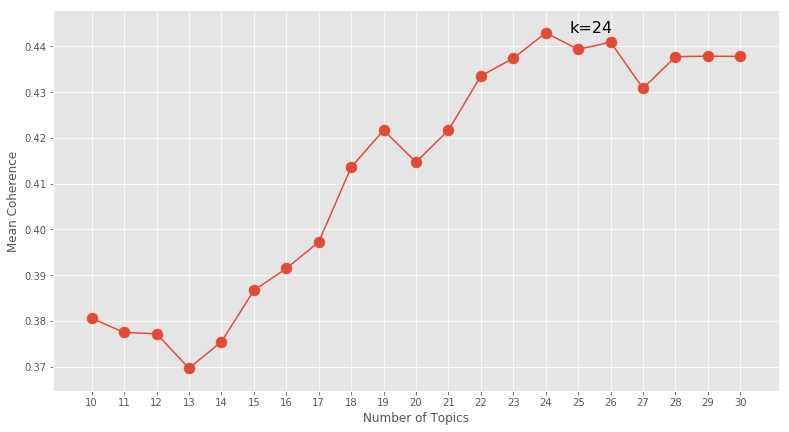

In [21]:
fig = plt.figure(figsize=(13,7))
# create the line plot
ax = plt.plot( k_values, coherences )
plt.xticks(k_values)
plt.xlabel("Number of Topics")
plt.ylabel("Mean Coherence")
# add the points
plt.scatter( k_values, coherences, s=120)
# find and annotate the maximum point on the plot
ymax = max(coherences)
xpos = coherences.index(ymax)
best_k = k_values[xpos]
plt.annotate( "k=%d" % best_k, xy=(best_k, ymax), xytext=(best_k, ymax), textcoords="offset points", fontsize=16)
# show the plot
plt.show()

### Examine the Final  Model

The plot above suggests that the most appropriate value for the number of topics is *k=8*.

In [22]:
k = best_k
# get the model that we generated earlier.
W = topic_models[k-kmin][1]
H = topic_models[k-kmin][2]

Display the topic descriptors for this model:

In [23]:
for topic_index in range(k):
    descriptor = get_descriptor( terms, H, topic_index, 10 )
    str_descriptor = ", ".join( descriptor )
    print("Topic %02d: %s" % ( topic_index+1, str_descriptor ) )

Topic 01: building, bedroom, city, foot, apartment, square, street, house, park, property
Topic 02: trump, republican, campaign, donald, cruz, nominee, candidate, presidential, clinton, hillary
Topic 03: game, player, team, goal, win, play, season, league, score, coach
Topic 04: company, stock, bank, market, price, investor, cent, oil, rise, business
Topic 05: gay, gun, orlando, mateen, people, shooting, attack, transgend, victim, nightclub
Topic 06: european, britain, union, europe, vote, british, referendum, brexit, bloc, leave
Topic 07: graduate, bride, groom, father, york, university, mother, couple, son, marry
Topic 08: met, collin, inning, game, harvey, run, pitch, hit, syndergaard, season
Topic 09: clinton, sander, campaign, democratic, primary, voter, delegate, obama, bernie, hillary
Topic 10: film, music, book, theater, play, musical, time, broadway, movie, song
Topic 11: article, nytime, misstate, com, mail, error, incorrectly, correction, misidentifie, comment
Topic 12: isla

In [24]:
# create the model using the best K
from sklearn import decomposition
model = decomposition.NMF( init="nndsvd", n_components=k ) 
# apply the model and extract the two factor matrices
W = model.fit_transform( A )
H = model.components_

In [25]:
import numpy as np
def get_descriptor( terms, H, topic_index, top ):
    # reverse sort the values to sort the indices
    top_indices = np.argsort( H[topic_index,:] )[::-1]
    # now get the terms corresponding to the top-ranked indices
    top_terms = []
    for term_index in top_indices[0:top]:
        top_terms.append( terms[term_index] )
    return top_terms

In [26]:
descriptors = []
for topic_index in range(k):
    descriptors.append( get_descriptor( terms, H, topic_index, 10 ) )
    str_descriptor = ", ".join( descriptors[topic_index] )
    print("Topic %02d: %s" % ( topic_index+1, str_descriptor ) )

Topic 01: building, bedroom, city, foot, apartment, square, street, property, park, house
Topic 02: trump, republican, campaign, donald, cruz, nominee, candidate, presidential, clinton, delegate
Topic 03: game, player, team, goal, win, play, season, league, score, coach
Topic 04: company, stock, bank, market, price, investor, cent, oil, rise, business
Topic 05: gay, gun, orlando, mateen, shooting, people, attack, transgend, victim, nightclub
Topic 06: european, britain, union, europe, vote, british, referendum, brexit, bloc, leave
Topic 07: graduate, bride, groom, father, york, university, mother, couple, son, marry
Topic 08: met, collin, inning, game, harvey, run, pitch, hit, syndergaard, season
Topic 09: clinton, sander, campaign, democratic, primary, voter, delegate, obama, bernie, hillary
Topic 10: woman, people, time, book, life, feel, write, look, love, story
Topic 11: article, nytime, misstate, com, mail, error, incorrectly, correction, misidentifie, comment
Topic 12: islamic, g

In [27]:
%matplotlib inline
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
plt.style.use("ggplot")
matplotlib.rcParams.update({"font.size": 14})

In [28]:
def plot_top_term_weights( terms, H, topic_index, top ):
    # get the top terms and their weights
    top_indices = np.argsort( H[topic_index,:] )[::-1]
    top_terms = []
    top_weights = []
    for term_index in top_indices[0:top]:
        top_terms.append( terms[term_index] )
        top_weights.append( H[topic_index,term_index] )
    # note we reverse the ordering for the plot
    top_terms.reverse()
    top_weights.reverse()
    # create the plot
    fig = plt.figure(figsize=(13,8))
    # add the horizontal bar chart
    ypos = np.arange(top)
    ax = plt.barh(ypos, top_weights, align="center", color="green",tick_label=top_terms)
    plt.xlabel("Term Weight",fontsize=14)
    plt.tight_layout()
    plt.show()

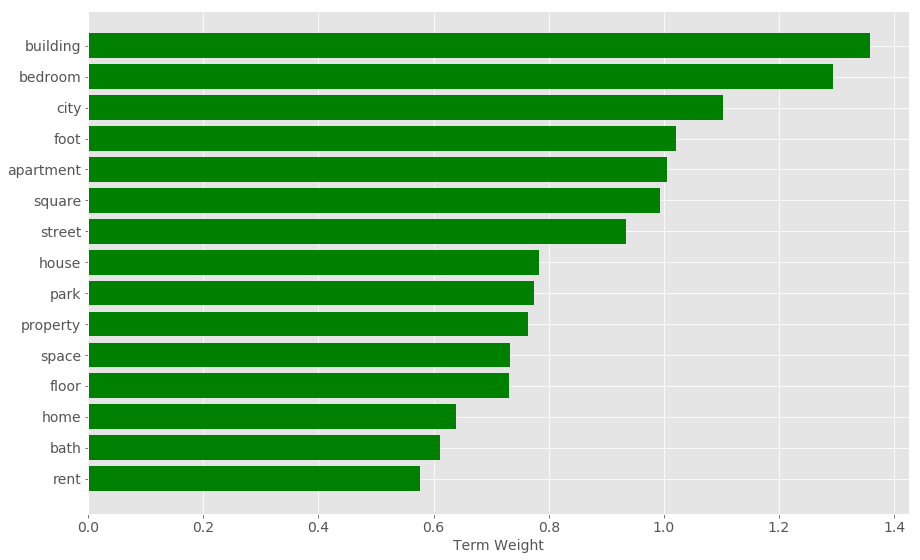

In [42]:
plot_top_term_weights( terms, H, 0, 15 )

In [29]:
def get_top_snippets( all_snippets, W, topic_index, top ):
    # reverse sort the values to sort the indices
    top_indices = np.argsort( W[:,topic_index] )[::-1]
    # now get the snippets corresponding to the top-ranked indices
    top_snippets = []
    for doc_index in top_indices[0:top]:
        top_snippets.append( all_snippets[doc_index] )
    return top_snippets

In [30]:
# display the documents involving topic 1
topic_snippets = get_top_snippets( snippets, W, 0, 10 )
for i, snippet in enumerate(topic_snippets):
    print("%02d. %s" % ( (i+1), snippet ) )

01. "ARNOLD, MD.WHAT: A brick Georgian with five bedrooms and three and a half bathrooms, plus a two-bed
02. "PARMA, N.Y.WHAT: A brick Victorian with five bedrooms, three and a half bathrooms, and an attached 
03. "A spacious penthouse at 150 Charles Street, the Witkoff Group’s new brick-and-glass condominium in 
04. "VERO BEACH, FLA.WHAT: A waterfront contemporary with three bedrooms and three bathroomsHOW MUCH: $2
05. "An elegant park-facing apartment on the entire fifth floor of 4 East 66th Street, a 1920 limestone 
06. "Two more luxury aeries officially closed at 432 Park Avenue, the tallest residential tower in the W
07. "ALBUQUERQUEWHAT: A house with three bedrooms and three bathrooms, plus a two-bedroom, one-bathroom 
08. "WOODSTOCK, N.Y.WHAT: A converted barn with a shop, four bedrooms, two full and two half bathrooms, 
09. "The tallest tower in the Western Hemisphere, 432 Park Avenue, continues to fill up, with the offici
10. "$1.475 million15 Gouverneur Place (at Washington A

In [31]:
# topic 2
topic_snippets = get_top_snippets( snippets, W, 1, 10 )
for i, snippet in enumerate(topic_snippets):
    print("%02d. %s" % ( (i+1), snippet ) )

01. "‘Have you seen the latest polls? I’m beating Hillary.”Donald Trump was on the phone with a man he h
02. "Democratic leaders nationwide sought to exact a political price from Republican officials and candi
03. "Donald Trump has been a familiar, if intermittent, presence in this magazine for more than three de
04. "BRIARCLIFF MANOR, N.Y. — Donald J. Trump, aided by two teleprompters, presented the version of hims
05. "They called him a madman, a con man, a cancer and worse during an ugly nominating fight, but in the
06. "AYRSHIRE, Scotland — His campaign is desperately short of cash. He has struggled to hire staff. Inf
07. "Andrew Beal, a billionaire banker and investor, called me the other day to talk Trump. I had been l
08. "WASHINGTON — Donald J. Trump and Speaker Paul D. Ryan appeared to take half a step back from their 
09. "In Las Vegas last week, Donald J. Trump’s Nevada headquarters stood dark. A sign taped to the door 
10. "Republican elected officials, donors and strategis

In [ ]:
#joblib.dump((W,H,terms,snippets), "articles-model-nmf-k%02d.pkl" % k) 